# AeroTwin — Complete C-MAPSS EDA, Preprocessing, RUL Model Comparison & Selection
This notebook implements the full pipeline for C-MAPSS RUL development, including multi-regime normalization and model comparison.

## 01. Project Configuration

In [19]:
import os
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Conv1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from IPython.display import display

# Configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CMAPSS_DIR = r"C:\Users\mohit\Documents\AeroTwin_datasets\6.+Turbofan+Engine+Degradation+Simulation+Data+Set\6. Turbofan Engine Degradation Simulation Data Set\CMAPSSData"
CACHE_DIR = "data/cache"
MODELS_DIR = "models"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook")

## 02. Imports & 03. Dataset Discovery
The goal is to explore FD001, FD002, FD003, and FD004 to build a robust model capable of handling multiple operating conditions and degradation modes.

## 04. Load C-MAPSS FD001–FD004

In [20]:
def load_cmapss_file(directory, filename, dataset_id):
    filepath = os.path.join(directory, filename)
    df = pd.read_csv(filepath, sep=r"\s+", header=None, engine="python")
    columns = ["unit_number", "time_in_cycles", "op_setting_1", "op_setting_2", "op_setting_3"] + [f"sensor_{i}" for i in range(1, 22)]
    df.columns = columns
    # Create globally unique engine ID
    df["dataset_id"] = dataset_id
    df["engine_id"] = df["dataset_id"] + "_" + df["unit_number"].astype(str)
    return df

print("Loading C-MAPSS Datasets...")
fd001 = load_cmapss_file(CMAPSS_DIR, "train_FD001.txt", "FD001")
print(f"FD001 Shape: {fd001.shape} (1 Op Condition, 1 Fault Mode)")

fd002 = load_cmapss_file(CMAPSS_DIR, "train_FD002.txt", "FD002")
print(f"FD002 Shape: {fd002.shape} (6 Op Conditions, 1 Fault Mode)")

fd003 = load_cmapss_file(CMAPSS_DIR, "train_FD003.txt", "FD003")
print(f"FD003 Shape: {fd003.shape} (1 Op Condition, 2 Fault Modes)")

fd004 = load_cmapss_file(CMAPSS_DIR, "train_FD004.txt", "FD004")
print(f"FD004 Shape: {fd004.shape} (6 Op Conditions, 2 Fault Modes)")

df_full = pd.concat([fd001, fd002, fd003, fd004], ignore_index=True)
print(f"Combined Shape: {df_full.shape}")

Loading C-MAPSS Datasets...
FD001 Shape: (20631, 28) (1 Op Condition, 1 Fault Mode)
FD002 Shape: (53759, 28) (6 Op Conditions, 1 Fault Mode)
FD003 Shape: (24720, 28) (1 Op Condition, 2 Fault Modes)
FD004 Shape: (61249, 28) (6 Op Conditions, 2 Fault Modes)
Combined Shape: (160359, 28)


## 05. Dataset Structure EDA & 06. Data Quality EDA

In [21]:
def dataset_summary(df):
    summary = []
    for ds_id in df['dataset_id'].unique():
        sub_df = df[df['dataset_id'] == ds_id]
        lifetimes = sub_df.groupby('engine_id')['time_in_cycles'].max()
        summary.append({
            "Dataset": ds_id,
            "Engines": sub_df['engine_id'].nunique(),
            "Rows": len(sub_df),
            "Mean Life": lifetimes.mean(),
            "Median Life": lifetimes.median(),
            "Max Life": lifetimes.max(),
            "Min Life": lifetimes.min()
        })
    return pd.DataFrame(summary)

display(dataset_summary(df_full))
print("Missing values:", df_full.isna().sum().sum())
print("Duplicate rows:", df_full.duplicated().sum())

,Dataset,Engines,Rows,Mean Life,Median Life,Max Life,Min Life
0,FD001,100,20631,206.310000,199.0,362,128
1,FD002,260,53759,206.765385,199.0,378,128
2,FD003,100,24720,247.200000,220.5,525,145
3,FD004,249,61249,245.979920,234.0,543,128


Missing values: 0
Duplicate rows: 0


## 07. Engine Lifetime EDA

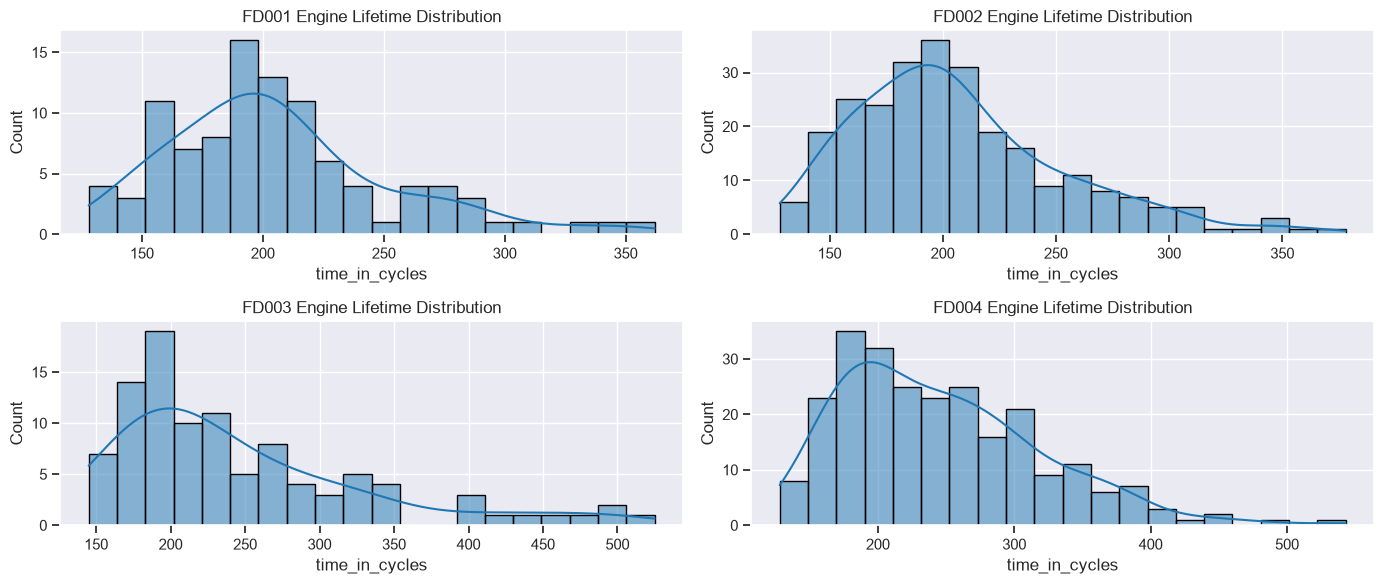

In [22]:
plt.figure(figsize=(14, 6))
for i, ds_id in enumerate(['FD001', 'FD002', 'FD003', 'FD004'], 1):
    plt.subplot(2, 2, i)
    lifetimes = df_full[df_full['dataset_id'] == ds_id].groupby('engine_id')['time_in_cycles'].max()
    sns.histplot(lifetimes, bins=20, kde=True)
    plt.title(f"{ds_id} Engine Lifetime Distribution")
plt.tight_layout()
plt.show()

## 08. Operating Condition EDA & 09. Sensor EDA

In [23]:
op_cols = ["op_setting_1", "op_setting_2", "op_setting_3"]
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
display(df_full[op_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
op_setting_1,160359.0,17.211973,16.527988,-0.0087,0.0013,19.9981,35.0015,42.008
op_setting_2,160359.0,0.410004,0.367938,-0.0006,0.0002,0.6200,0.8400,0.842
op_setting_3,160359.0,95.724344,12.359044,60.0000,100.0000,100.0000,100.0000,100.000


## 10. Sensor Variance / Constant Sensor Analysis

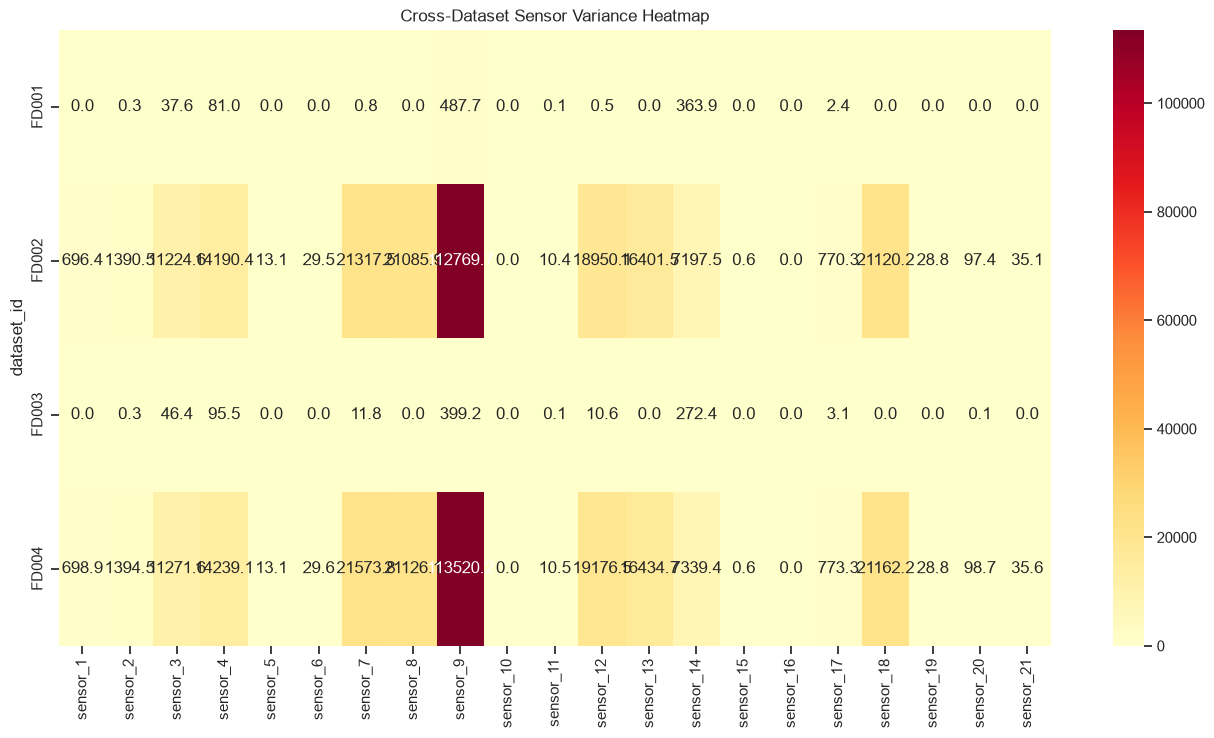

In [24]:
sensor_variances = df_full.groupby('dataset_id')[sensor_cols].var()
plt.figure(figsize=(16, 8))
sns.heatmap(sensor_variances, annot=True, cmap="YlOrRd", fmt=".1f", cbar=True)
plt.title("Cross-Dataset Sensor Variance Heatmap")
plt.show()

## 11. Visualize All 21 Sensors & Sensor Degradation Analysis

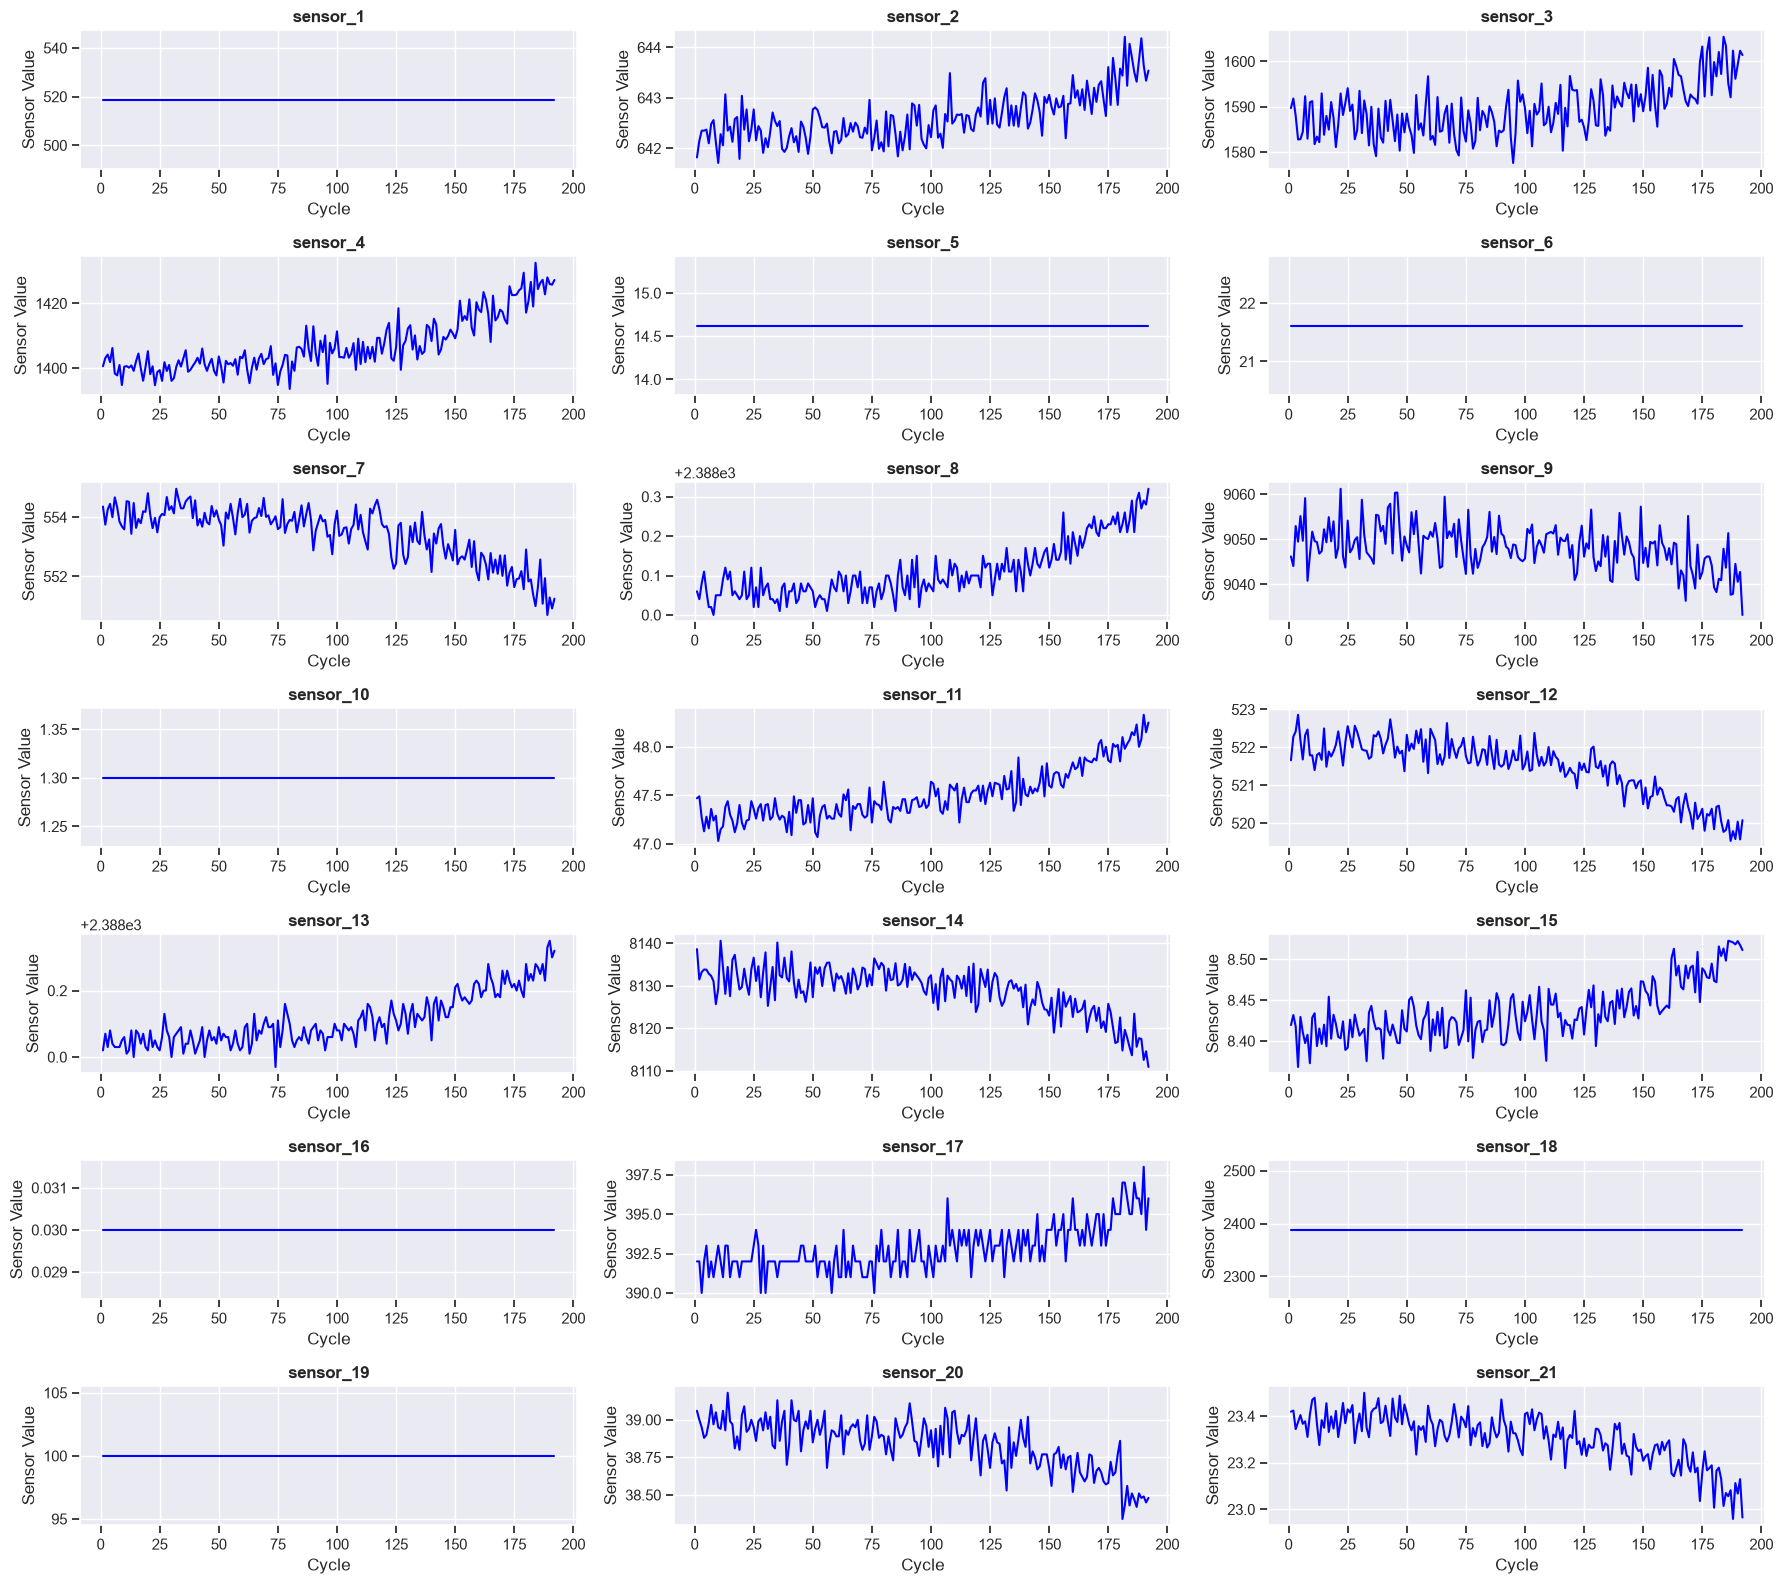

In [25]:
unit = df_full[df_full['engine_id'] == 'FD001_1']
fig, axes = plt.subplots(7, 3, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(sensor_cols):
    axes[i].plot(unit['time_in_cycles'], unit[col], color='blue')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel("Cycle")
    axes[i].set_ylabel("Sensor Value")
plt.tight_layout()
plt.show()

## 14. Preprocessing Design & 16. Sensor Selection
From variance analysis, we identify constant/uninformative sensors for FD001 (and others). The existing AeroTwin architecture expects 14 sensors.
We will drop the 7 sensors typically identified as constant in baseline literature (1, 5, 6, 10, 16, 18, 19).

In [26]:
drop_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
selected_sensors = [s for s in sensor_cols if s not in drop_sensors]

print("Removed sensors:", drop_sensors)
print("Selected sensors:", selected_sensors)
print("Number of selected sensors:", len(selected_sensors))

EXPECTED_CMAPSS_FEATURE_COUNT = 14
assert len(selected_sensors) == EXPECTED_CMAPSS_FEATURE_COUNT, "Architecture mismatch!"

df_full = df_full.drop(columns=drop_sensors)

Removed sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Selected sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Number of selected sensors: 14


## 17. RUL Construction & 21. RUL Distribution

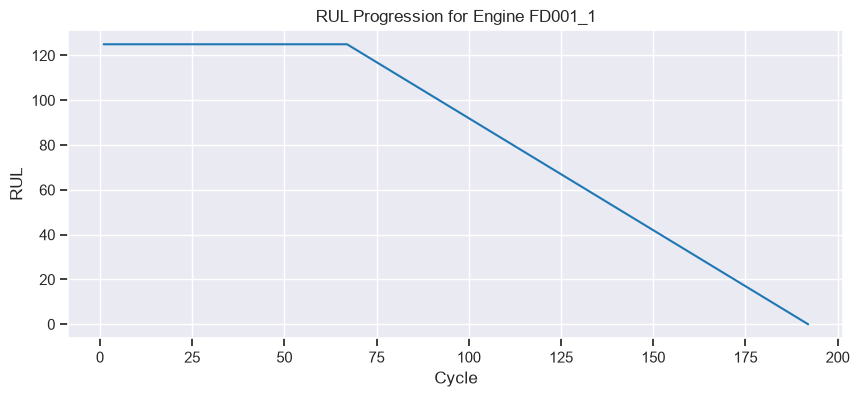

In [27]:
RUL_CAP = 125
max_cycles = df_full.groupby("engine_id")["time_in_cycles"].transform("max")
df_full["RUL"] = max_cycles - df_full["time_in_cycles"]
df_full["RUL"] = df_full["RUL"].clip(upper=RUL_CAP)

plt.figure(figsize=(10, 4))
plt.plot(unit['time_in_cycles'], df_full[df_full['engine_id'] == 'FD001_1']['RUL'])
plt.title("RUL Progression for Engine FD001_1")
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.show()

## 15. Engine-Level Train/Validation/Test Split

In [28]:
# We split by engine_id to prevent leakage
gss_train = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=SEED)
train_idx, temp_idx = next(gss_train.split(df_full, groups=df_full['engine_id']))
train_df = df_full.iloc[train_idx].copy()
temp_df = df_full.iloc[temp_idx].copy()

gss_val = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED)
val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['engine_id']))
val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print(f"Train engines: {train_df['engine_id'].nunique()} | Val engines: {val_df['engine_id'].nunique()} | Test engines: {test_df['engine_id'].nunique()}")

Train engines: 496 | Val engines: 106 | Test engines: 107


## 21-24. Operating-Regime Clustering (Experimental)
We test K=2 to 8 to see if there is a natural clustering of operational settings, without assuming K=6 beforehand.

K=2 completed (Inertia: 127857.19, Silhouette: 0.6908)
K=3 completed (Inertia: 22910.37, Silhouette: 0.8471)
K=4 completed (Inertia: 9364.01, Silhouette: 0.8593)
K=5 completed (Inertia: 1379.50, Silhouette: 0.9502)
K=6 completed (Inertia: 0.29, Silhouette: 0.9977)
K=7 completed (Inertia: 0.24, Silhouette: 0.9567)
K=8 completed (Inertia: 0.19, Silhouette: 0.8487)


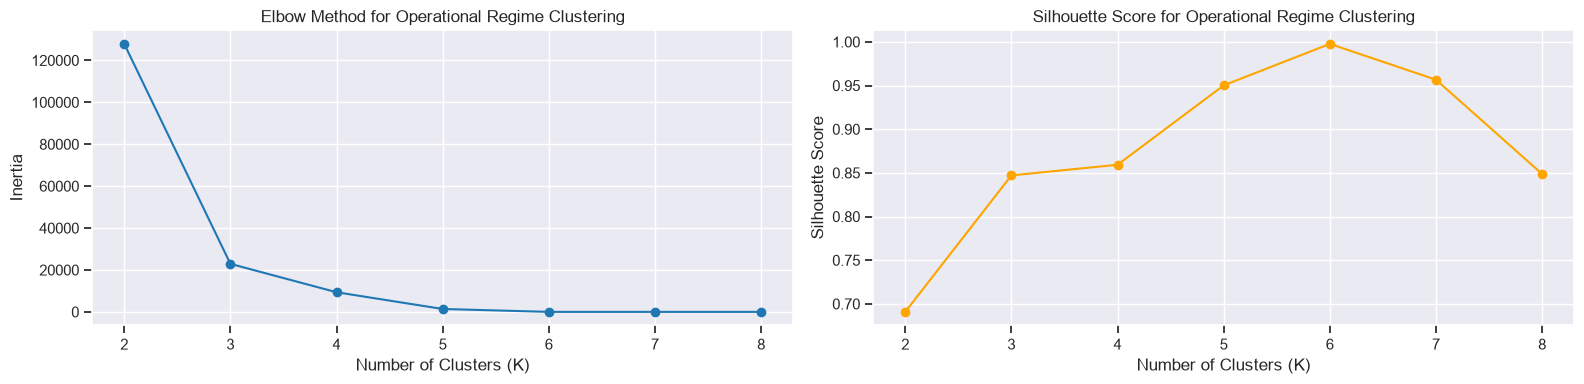

Selected K=6 based on maximum Silhouette Score: 0.9977


In [29]:
op_scaler = StandardScaler()
train_op = op_scaler.fit_transform(train_df[op_cols])

# Elbow and Silhouette Analysis
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(train_op)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(train_op, labels, sample_size=10000, random_state=SEED)
    silhouette_scores.append(score)
    print(f"K={k} completed (Inertia: {kmeans.inertia_:.2f}, Silhouette: {score:.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# Elbow Plot
ax1.plot(K_range, inertias, marker='o')
ax1.set_title("Elbow Method for Operational Regime Clustering")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")

# Silhouette Plot
ax2.plot(K_range, silhouette_scores, marker='o', color='orange')
ax2.set_title("Silhouette Score for Operational Regime Clustering")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

# Select K based on the highest Silhouette Score
best_k_idx = np.argmax(silhouette_scores)
K = K_range[best_k_idx]
print(f"Selected K={K} based on maximum Silhouette Score: {silhouette_scores[best_k_idx]:.4f}")

# Train final KMeans with best K
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
train_df['regime'] = kmeans.fit_predict(train_op)
val_df['regime'] = kmeans.predict(op_scaler.transform(val_df[op_cols]))
test_df['regime'] = kmeans.predict(op_scaler.transform(test_df[op_cols]))

## 18. Regime Normalization & Scaling
Apply StandardScaler independently within each cluster.

In [30]:
regime_scalers = {i: StandardScaler() for i in range(K)}
for i in range(K):
    mask = train_df['regime'] == i
    regime_scalers[i].fit(train_df.loc[mask, selected_sensors])

def apply_regime_scaling(df, scalers, k_model, op_scale):
    df_scaled = df.copy()
    regimes = k_model.predict(op_scale.transform(df[op_cols]))
    df_scaled['regime'] = regimes
    df_scaled[selected_sensors] = df_scaled[selected_sensors].astype(float)
    for i in range(len(scalers)):
        mask = df_scaled['regime'] == i
        if mask.any():
            df_scaled.loc[mask, selected_sensors] = scalers[i].transform(df_scaled.loc[mask, selected_sensors])
    return df_scaled

train_df = apply_regime_scaling(train_df, regime_scalers, kmeans, op_scaler)
val_df = apply_regime_scaling(val_df, regime_scalers, kmeans, op_scaler)
test_df = apply_regime_scaling(test_df, regime_scalers, kmeans, op_scaler)

## 19. Rolling Smoothing & 20. Baseline Alignment

In [31]:
def apply_smoothing(df, window=5):
    df = df.copy()
    df[selected_sensors] = df.groupby('engine_id')[selected_sensors].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    return df

train_df = apply_smoothing(train_df)
val_df = apply_smoothing(val_df)
test_df = apply_smoothing(test_df)

def apply_baseline_alignment(df):
    df = df.copy()
    baselines = df[df["time_in_cycles"] <= 10].groupby("engine_id")[selected_sensors].mean()
    for engine, baseline_vals in baselines.iterrows():
        mask = df["engine_id"] == engine
        df.loc[mask, selected_sensors] = df.loc[mask, selected_sensors] - baseline_vals
    return df

train_df = apply_baseline_alignment(train_df)
val_df = apply_baseline_alignment(val_df)
test_df = apply_baseline_alignment(test_df)

## 25. Sequence Generation (30-Cycle)

In [32]:
SEQUENCE_LENGTH = 30

def generate_sequences(df):
    X, y = [], []
    for engine_id, group in df.groupby("engine_id"):
        features = group[selected_sensors].values
        labels = group["RUL"].values
        for i in range(len(features) - SEQUENCE_LENGTH + 1):
            X.append(features[i : i + SEQUENCE_LENGTH])
            y.append(labels[i + SEQUENCE_LENGTH - 1])
    return np.array(X), np.array(y)

print("Generating sequences...")
X_train, y_train = generate_sequences(train_df)
X_val, y_val = generate_sequences(val_df)
X_test, y_test = generate_sequences(test_df)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

Generating sequences...
X_train shape: (98582, 30, 14), y_train shape: (98582,)
X_val shape: (20575, 30, 14), y_val shape: (20575,)


## 27. Cache Export & 35. Preprocessor Artifact

In [33]:
cache_data = {
    "X_train": X_train, "y_train": y_train,
    "X_val": X_val, "y_val": y_val,
    "X_test": X_test, "y_test": y_test,
    "train_engine_ids": train_df['engine_id'].unique(),
    "val_engine_ids": val_df['engine_id'].unique(),
    "test_engine_ids": test_df['engine_id'].unique(),
    "feature_names": selected_sensors,
    "sequence_length": SEQUENCE_LENGTH,
    "rul_cap": RUL_CAP
}
with open(os.path.join(CACHE_DIR, "cmapss_full_processed.pkl"), "wb") as f:
    pickle.dump(cache_data, f)

preprocessors = {
    "op_scaler": op_scaler,
    "kmeans": kmeans,
    "regime_scalers": regime_scalers,
    "selected_sensors": selected_sensors
}
with open(os.path.join(CACHE_DIR, "cmapss_preprocessors.pkl"), "wb") as f:
    pickle.dump(preprocessors, f)

print("Caches successfully exported!")

Caches successfully exported!


## 37. RUL Model Comparison & Definitions (29-33)
We define LSTM, GRU, BiLSTM, and CNN-LSTM models for fair comparison.

In [34]:
INPUT_SHAPE = (SEQUENCE_LENGTH, len(selected_sensors))

def build_lstm_model():
    model = Sequential([
        LSTM(64, input_shape=INPUT_SHAPE, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ], name="LSTM_Baseline")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_gru_model():
    model = Sequential([
        GRU(64, input_shape=INPUT_SHAPE, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ], name="GRU_Lighter")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_bilstm_model():
    model = Sequential([
        Bidirectional(LSTM(32, return_sequences=True), input_shape=INPUT_SHAPE),
        Dropout(0.2),
        Bidirectional(LSTM(16)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ], name="BiLSTM_Temporal")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_cnn_lstm_model():
    model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=INPUT_SHAPE),
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ], name="CNN_LSTM_Hybrid")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

models_dict = {
    "LSTM": build_lstm_model(),
    "GRU": build_gru_model(),
    "BiLSTM": build_bilstm_model(),
    "CNN-LSTM": build_cnn_lstm_model()
}

c:\Users\mohit\Documents\AeroTwin\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\mohit\Documents\AeroTwin\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:110: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\mohit\Documents\AeroTwin\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 42. Fair Training Procedure

In [35]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
BATCH_SIZE = 512
EPOCHS = 50

history_dict = {}
for name, model in models_dict.items():
    print(f"\nTraining {name} Model (Params: {model.count_params()})...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[early_stopping],
        verbose=1
    )
    history_dict[name] = history


Training LSTM Model (Params: 33729)...
Epoch 1/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - loss: 5701.8774 - mae: 65.1787 - val_loss: 2415.6482 - val_mae: 43.8253
Epoch 2/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - loss: 1598.4791 - mae: 34.9016 - val_loss: 452.3958 - val_mae: 18.5389
Epoch 3/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - loss: 339.7255 - mae: 14.4038 - val_loss: 273.6963 - val_mae: 12.3480
Epoch 4/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - loss: 283.1717 - mae: 12.7885 - val_loss: 263.6509 - val_mae: 11.6821
Epoch 5/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - loss: 267.0439 - mae: 12.4026 - val_loss: 263.9576 - val_mae: 11.5477
Epoch 6/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 256.3080 - mae: 12.1297 - val_loss: 262.4060 - val_mae: 11.6046
Epoch 7/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - loss: 246.3478 - mae: 11.8940 - val_loss: 260.3608 - val_mae: 11.5536
Epoch 8/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 239.6637 - ma

## 43-47. Overall Model Comparison & Selection

In [36]:
results = []
for name, model in models_dict.items():
    val_preds = model.predict(X_val, verbose=0).flatten()
    mae = mean_absolute_error(y_val, val_preds)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    r2 = r2_score(y_val, val_preds)
    results.append({
        "Model": name,
        "Val MAE": mae,
        "Val RMSE": rmse,
        "Val R2": r2,
        "Params": model.count_params()
    })

comparison_df = pd.DataFrame(results).sort_values("Val MAE")
display(comparison_df)

# Selection criteria: Best Val MAE/RMSE considering Params cost
best_model_name = comparison_df.iloc[0]["Model"]
best_model = models_dict[best_model_name]
print(f"\nSelected Best Model: {best_model_name}")

,Model,Val MAE,Val RMSE,Val R2,Params
1,GRU,10.488023,15.137279,0.869062,25857
0,LSTM,11.553558,16.135701,0.851219,33729
2,BiLSTM,12.245666,16.659920,0.841395,23489
3,CNN-LSTM,12.403710,16.954437,0.835738,13889



Selected Best Model: GRU


## 37. Final Test Evaluation

In [37]:
print(f"Evaluating {best_model_name} on untouched Test Set...")
test_preds = best_model.predict(X_test, verbose=0).flatten()
test_mae = mean_absolute_error(y_test, test_preds)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)

print(f"Test MAE: {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R²: {test_r2:.3f}")

Evaluating GRU on untouched Test Set...
Test MAE: 9.81
Test RMSE: 14.62
Test R²: 0.878


## 48-52. Evaluation Visualizations

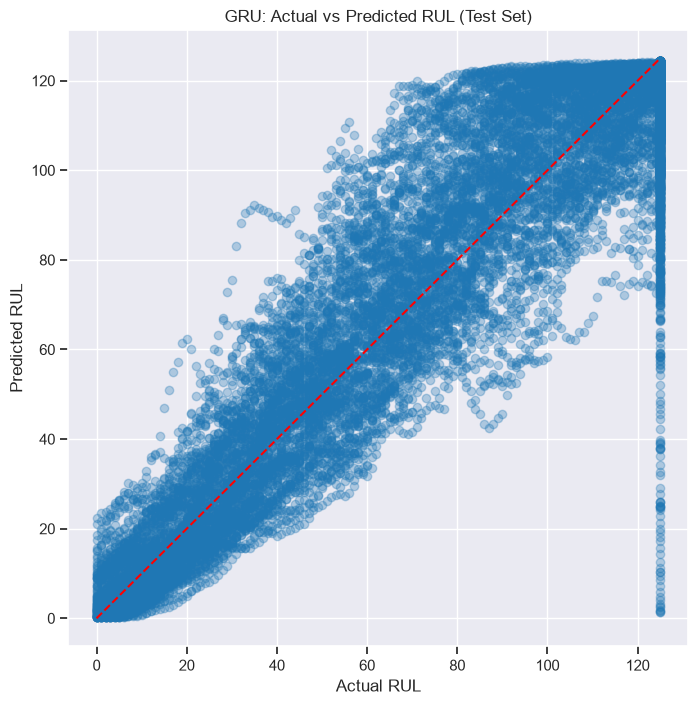

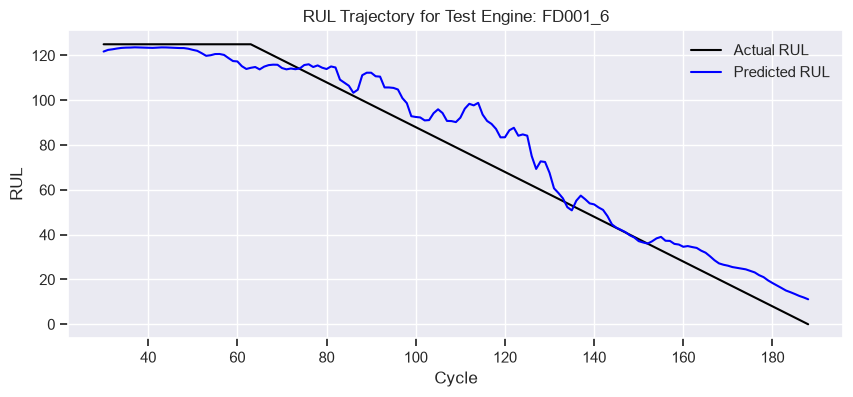

In [38]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, test_preds, alpha=0.3)
plt.plot([0, RUL_CAP], [0, RUL_CAP], color='red', linestyle='--')
plt.title(f"{best_model_name}: Actual vs Predicted RUL (Test Set)")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.show()

# RUL Trajectory Plot for a Test Engine
test_engines = test_df['engine_id'].unique()
if len(test_engines) > 0:
    sample_engine = test_engines[0]
    mask = test_df['engine_id'] == sample_engine
    
    engine_data = test_df[mask]
    engine_X, engine_y = generate_sequences(engine_data)
    if len(engine_X) > 0:
        engine_preds = best_model.predict(engine_X, verbose=0).flatten()
        cycles = engine_data['time_in_cycles'].values[SEQUENCE_LENGTH-1:]
        
        plt.figure(figsize=(10, 4))
        plt.plot(cycles, engine_y, label="Actual RUL", color='black')
        plt.plot(cycles, engine_preds, label="Predicted RUL", color='blue')
        plt.title(f"RUL Trajectory for Test Engine: {sample_engine}")
        plt.xlabel("Cycle")
        plt.ylabel("RUL")
        plt.legend()
        plt.show()

## 53. Save the Best Model & Metadata

In [39]:
model_path = os.path.join(MODELS_DIR, "best_rul_model.keras")
best_model.save(model_path)
print(f"Saved {best_model_name} to {model_path}")

metadata = {
    "model_name": best_model_name,
    "feature_count": len(selected_sensors),
    "sequence_length": SEQUENCE_LENGTH,
    "rul_cap": RUL_CAP,
    "test_mae": test_mae,
    "test_rmse": test_rmse,
    "test_r2": test_r2
}
with open(os.path.join(MODELS_DIR, "best_rul_model_meta.pkl"), "wb") as f:
    pickle.dump(metadata, f)

print("Pipeline Complete! Preprocessed caches and trained models are ready for the backend.")

Saved GRU to models\best_rul_model.keras
Pipeline Complete! Preprocessed caches and trained models are ready for the backend.
